In [20]:
import requests
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
from collections import Counter
import json

# Set visualization style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# API 

## API's

In [21]:
API_KEY = "PeqtKANF3zHPj8AF5IWpZtCaWDMKZpO9YOmNEMZvGk2JbPjA"

url_ny = "https://api.nytimes.com/svc/news/v3/content/nyt/world.json"


'''
    Simple request function
'''
def get_sample_data(url, api_key=API_KEY):
    headers = {
        'api-key': api_key
        }

    response = requests.request("GET", url, params=headers)
    if response.status_code == 200:
        return response.json()
    else:
        return f"Error: {response.status_code}"

response = get_sample_data(url_ny)
print(response.keys())

dict_keys(['status', 'copyright', 'num_results', 'results'])


In [22]:
base_url_most_popular = 'https://api.nytimes.com/svc/mostpopular/v2/'
url_30_newest = base_url_most_popular + "viewed/30.json"

response = get_sample_data(url_30_newest)
print(f"There are {len(response['results'])} different news retrieved")
for res in response['results']:
    print("Title: {}, Source: {}".format(res['title'], res['url'])) 

There are 20 different news retrieved
Title: The Government Published Dozens of Nude Photos in the Epstein Files, Source: https://www.nytimes.com/2026/02/01/us/nude-photos-epstein-files.html
Title: How Trump Appears in the Epstein Files, Source: https://www.nytimes.com/2026/02/01/us/trump-epstein-files.html
Title: Trump Had Unusual Call With F.B.I. Agents After Election Center Search, Source: https://www.nytimes.com/2026/02/02/us/politics/trump-fbi-phone-call-georgia-gabbard.html
Title: U.S. Attacked Boat With Aircraft That Looked Like a Civilian Plane, Source: https://www.nytimes.com/2026/01/12/us/politics/us-boat-attacks-law.html
Title: Trump Announces New European Tariffs in Greenland Standoff; Allies Outraged, Source: https://www.nytimes.com/2026/01/17/us/politics/trump-eu-tariffs-greenland.html
Title: ‘I Didn’t Make a Mistake’: Trump Declines to Apologize for Racist Video of Obamas, Source: https://www.nytimes.com/2026/02/06/us/politics/trump-obamas-video-apes-truth-social.html
Ti

In [23]:
import requests
# Usually we will not store the API key in the code.
API_KEY = "PeqtKANF3zHPj8AF5IWpZtCaWDMKZpO9YOmNEMZvGk2JbPjA"

url_ny = "https://api.nytimes.com/svc/news/v3/content/nyt/world.json"


'''
    Simple request function
'''
def get_sample_data(url, api_key=API_KEY):
    headers = {
        'api-key': api_key
        }

    response = requests.request("GET", url, params=headers)
    if response.status_code == 200:
        return response.json()
    else:
        return f"Error: {response.status_code}"

response = get_sample_data(url_ny)
print(response.keys())

base_url_most_popular = 'https://api.nytimes.com/svc/mostpopular/v2/'
url_30_newest = base_url_most_popular + "viewed/30.json"

response = get_sample_data(url_30_newest)
print(f"There are {len(response['results'])} different news retrieved")
for res in response['results']:
    print("Title: {}, Source: {}".format(res['title'], res['url'])) 

dict_keys(['status', 'copyright', 'num_results', 'results'])
There are 20 different news retrieved
Title: The Government Published Dozens of Nude Photos in the Epstein Files, Source: https://www.nytimes.com/2026/02/01/us/nude-photos-epstein-files.html
Title: How Trump Appears in the Epstein Files, Source: https://www.nytimes.com/2026/02/01/us/trump-epstein-files.html
Title: Trump Had Unusual Call With F.B.I. Agents After Election Center Search, Source: https://www.nytimes.com/2026/02/02/us/politics/trump-fbi-phone-call-georgia-gabbard.html
Title: U.S. Attacked Boat With Aircraft That Looked Like a Civilian Plane, Source: https://www.nytimes.com/2026/01/12/us/politics/us-boat-attacks-law.html
Title: Trump Announces New European Tariffs in Greenland Standoff; Allies Outraged, Source: https://www.nytimes.com/2026/01/17/us/politics/trump-eu-tariffs-greenland.html
Title: ‘I Didn’t Make a Mistake’: Trump Declines to Apologize for Racist Video of Obamas, Source: https://www.nytimes.com/2026/0

## Trying rapidapi

In [24]:
### This shit cost money? Heck nah!
url = "https://text-sentiment.p.rapidapi.com/analyze"

payload = "text=I am so happy today... hmm, no, I'm actually quite sad... wait!"
headers = {
    'content-type': "application/x-www-form-urlencoded",
    'x-rapidapi-host': "text-sentiment.p.rapidapi.com",
    'x-rapidapi-key': "c6b22dbe22mshbb0e1a20d0bc401p1bc141jsnd0e35c678ea1"
    }
response = requests.request("POST", url, data=payload, headers=headers).json()
print(response)

{'message': 'You are not subscribed to this API.'}


## Building stuff

In [25]:
# NYT API Configuration
API_KEY = "PeqtKANF3zHPj8AF5IWpZtCaWDMKZpO9YOmNEMZvGk2JbPjA"
BASE_URL_SEARCH = "https://api.nytimes.com/svc/search/v2/articlesearch.json"
BASE_URL_POPULAR = "https://api.nytimes.com/svc/mostpopular/v2/viewed/7.json"

'''
    Secure API request function with error handling
'''
def make_api_request(url, params=None, api_key=API_KEY):
    """
    Make a GET request to NYT API with proper error handling
    """
    if params is None:
        params = {}
    
    params['api-key'] = api_key
    
    try:
        response = requests.get(url, params=params, timeout=10)
        response.raise_for_status()
        
        if response.status_code == 200:
            return response.json()
        else:
            return {"error": f"Status Code: {response.status_code}"}
    
    except requests.exceptions.Timeout:
        return {"error": "Request timed out"}
    except requests.exceptions.ConnectionError:
        return {"error": "Connection error"}
    except Exception as e:
        return {"error": f"Error: {str(e)}"}

print("API Configuration loaded successfully")

API Configuration loaded successfully


In [26]:
def search_articles(query, pages=3, sort_by="newest"):
    """
    Search for articles by keyword/topic across multiple pages
    
    Args:
        query (str): Search term
        pages (int): Number of pages to retrieve
        sort_by (str): "newest" or "relevance"
    
    Returns:
        list: List of articles
    """
    all_articles = []
    
    for page in range(pages):
        params = {
            'q': query,
            'sort': sort_by,
            'page': page
        }
        
        response = make_api_request(BASE_URL_SEARCH, params)
        
        if 'response' in response and 'docs' in response['response']:
            articles = response['response']['docs']
            all_articles.extend(articles)
            print(f"Page {page + 1}: Retrieved {len(articles)} articles")
        else:
            print(f"Error on page {page + 1}: {response.get('error', 'Unknown error')}")
            break
    
    return all_articles

# Example: Search for articles about AI
query = "artificial intelligence"
articles = search_articles(query, pages=2)
print(f"\nTotal articles retrieved: {len(articles)}")

Page 1: Retrieved 10 articles
Page 2: Retrieved 10 articles

Total articles retrieved: 20


In [27]:
def parse_articles_to_dataframe(articles):
    """
    Convert raw API response articles into a pandas DataFrame
    """
    parsed_articles = []
    
    for article in articles:
        parsed_articles.append({
            'title': article.get('headline', {}).get('main', 'N/A'),
            'abstract': article.get('abstract', 'N/A'),
            'byline': article.get('byline', {}).get('original', 'N/A'),
            'source': article.get('source', 'N/A'),
            'pub_date': article.get('pub_date', 'N/A'),
            'news_desk': article.get('news_desk', 'N/A'),
            'section': article.get('section_name', 'N/A'),
            'url': article.get('web_url', 'N/A'),
            'word_count': article.get('word_count', 0),
            'document_type': article.get('document_type', 'N/A')
        })
    
    df = pd.DataFrame(parsed_articles)
    
    # Convert pub_date to datetime
    df['pub_date'] = pd.to_datetime(df['pub_date'], errors='coerce')
    
    return df

# Convert our articles to DataFrame
df_articles = parse_articles_to_dataframe(articles)
print("DataFrame created successfully!")
print(f"Shape: {df_articles.shape}")
print("\nFirst few articles:")
df_articles[['title', 'pub_date', 'source', 'word_count']].head()

DataFrame created successfully!
Shape: (20, 10)

First few articles:


,title,pub_date,source,word_count
0,Lamenting ‘Our President’s Overt Racism’,2026-02-09 17:40:56+00:00,The New York Times,624
1,A.I. Is Making Doctors Answer a Question: What...,2026-02-09 17:17:56+00:00,The New York Times,1835
2,Health Advice From A.I. Chatbots Is Frequently...,2026-02-09 16:21:58+00:00,The New York Times,1115
3,A.I. Blitzes the Big Game,2026-02-09 13:34:33+00:00,The New York Times,1844
4,Hollywood Braces for New Round of Labor Talks,2026-02-09 10:02:51+00:00,The New York Times,679


In [ ]:
def calculate_statistics(df):
    """
    Calculate comprehensive statistics about the articles
    """
    stats = {}
    
    # Basic counts
    stats['total_articles'] = len(df)
    stats['avg_word_count'] = df['word_count'].mean()
    
    # Source analysis
    stats['top_sources'] = df['source'].value_counts().head(5)
    stats['top_sections'] = df['section'].value_counts().head(5)
    
    # Time analysis
    if 'pub_date' in df.columns and len(df) > 0:
        df_with_dates = df.dropna(subset=['pub_date'])
        if len(df_with_dates) > 0:
            df_with_dates['day_of_week'] = df_with_dates['pub_date'].dt.day_name()
            stats['articles_by_day'] = df_with_dates['day_of_week'].value_counts()
    
    # Keyword extraction from titles
    all_words = ' '.join(df['title'].fillna('')).lower().split()
    # Filter out common words
    stop_words = {'the', 'a', 'an', 'and', 'or', 'in', 'to', 'of', 'is', 'at', 'for', 'by', 'on'}
    filtered_words = [w for w in all_words if w not in stop_words and len(w) > 3]
    stats['top_keywords'] = Counter(filtered_words).most_common(10)
    
    return stats

# Calculate statistics
stats = calculate_statistics(df_articles)

=== ARTICLE STATISTICS ===
Total Articles: 20
Average Word Count: 1640.2

Top Sources:
source
The New York Times    20
Name: count, dtype: int64

Top Sections:
section
Business      7
Opinion       3
Technology    2
Health        1
Well          1
Name: count, dtype: int64

Top Keywords:
  a.i.: 9
  they: 3
  these: 2
  change: 2
  test: 2
  elon: 2
  tech: 2
  spending: 2
  race: 2
  lamenting: 1


=== ARTICLE STATISTICS ===
Total Articles: 20
Average Word Count: 1640.2

Top Sources:
source
The New York Times    20
Name: count, dtype: int64

Top Sections:
section
Business      7
Opinion       3
Technology    2
Health        1
Well          1
Name: count, dtype: int64

Top Keywords:
  a.i.: 9
  they: 3
  these: 2
  change: 2
  test: 2
  elon: 2
  tech: 2
  spending: 2
  race: 2
  lamenting: 1


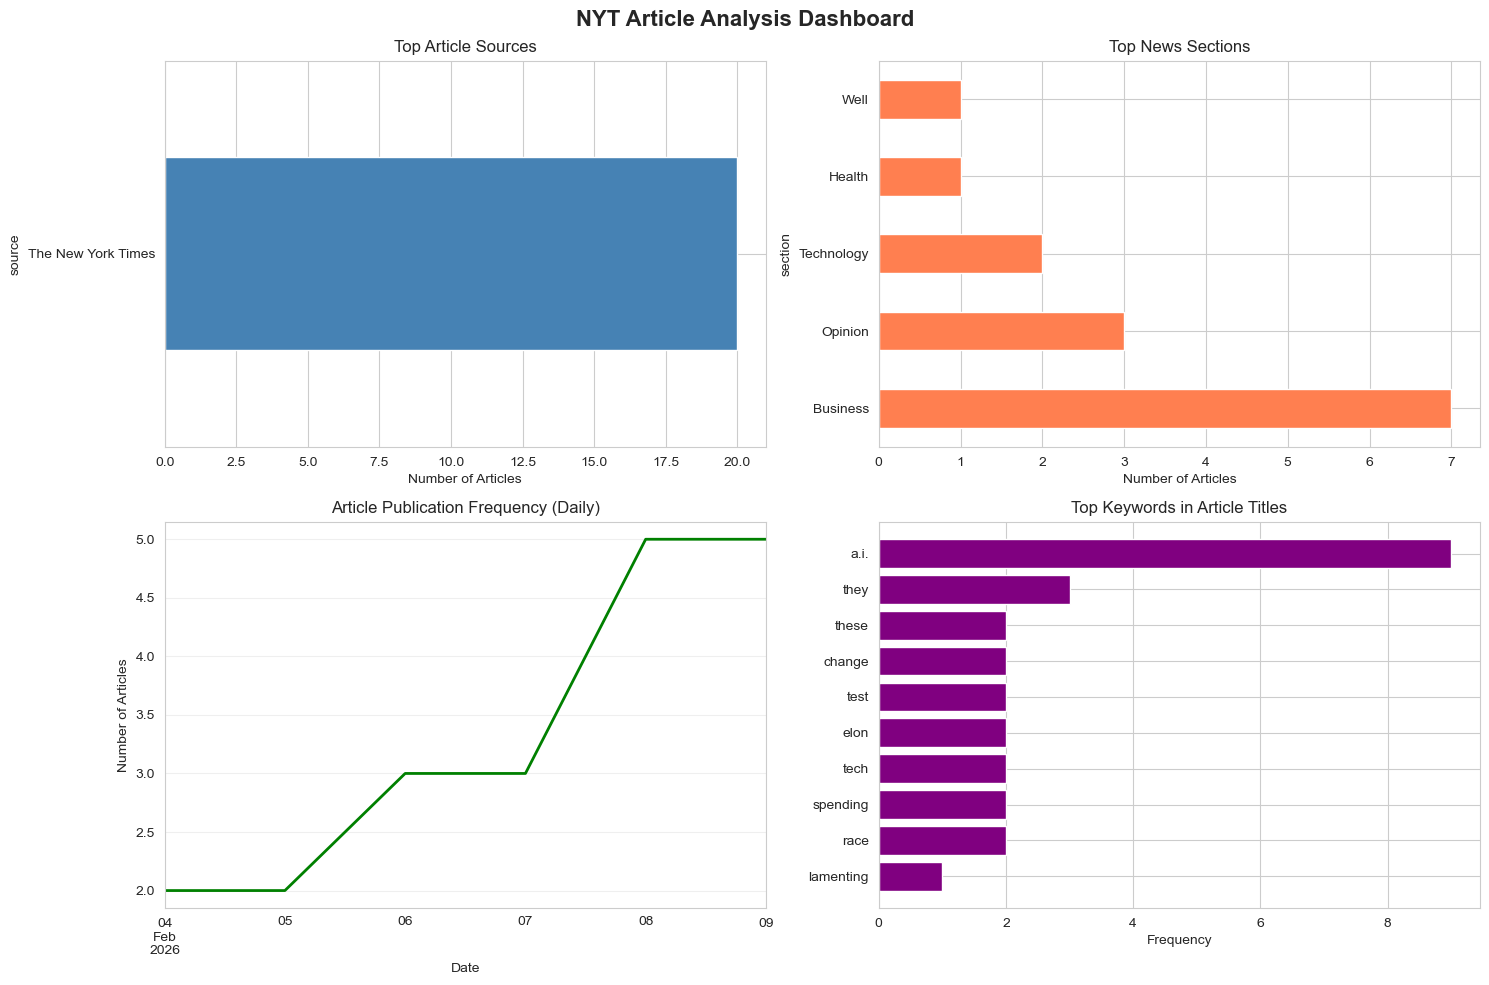

In [32]:
def visualize_trends(df, stats):
    """
    Create comprehensive visualizations of article trends
    """
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    fig.suptitle('NYT Article Analysis Dashboard', fontsize=16, fontweight='bold')
    
    # 1. Articles by Source
    ax1 = axes[0, 0]
    stats['top_sources'].plot(kind='barh', ax=ax1, color='steelblue')
    ax1.set_title('Top Article Sources')
    ax1.set_xlabel('Number of Articles')
    
    # 2. Articles by Section
    ax2 = axes[0, 1]
    stats['top_sections'].plot(kind='barh', ax=ax2, color='coral')
    ax2.set_title('Top News Sections')
    ax2.set_xlabel('Number of Articles')
    
    # 3. Articles over time
    ax3 = axes[1, 0]
    df_with_dates = df.dropna(subset=['pub_date'])
    if len(df_with_dates) > 0:
        df_time = df_with_dates.set_index('pub_date').resample('D').size()
        df_time.plot(ax=ax3, color='green', linewidth=2)
        ax3.set_title('Article Publication Frequency (Daily)')
        ax3.set_xlabel('Date')
        ax3.set_ylabel('Number of Articles')
        ax3.grid(True, alpha=0.3)
    
    # 4. Top Keywords
    ax4 = axes[1, 1]
    keywords, counts = zip(*stats['top_keywords'][:10])
    ax4.barh(range(len(keywords)), counts, color='purple')
    ax4.set_yticks(range(len(keywords)))
    ax4.set_yticklabels(keywords)
    ax4.set_title('Top Keywords in Article Titles')
    ax4.set_xlabel('Frequency')
    ax4.invert_yaxis()
    
    plt.tight_layout()
    plt.show()

print("=== ARTICLE STATISTICS ===")
print(f"Total Articles: {stats['total_articles']}")
print(f"Average Word Count: {stats['avg_word_count']:.1f}")
print(f"\nTop Sources:")
print(stats['top_sources'])
print(f"\nTop Sections:")
print(stats['top_sections'])
print(f"\nTop Keywords:")
for keyword, count in stats['top_keywords']:
    print(f"  {keyword}: {count}")

visualize_trends(df_articles, stats)
